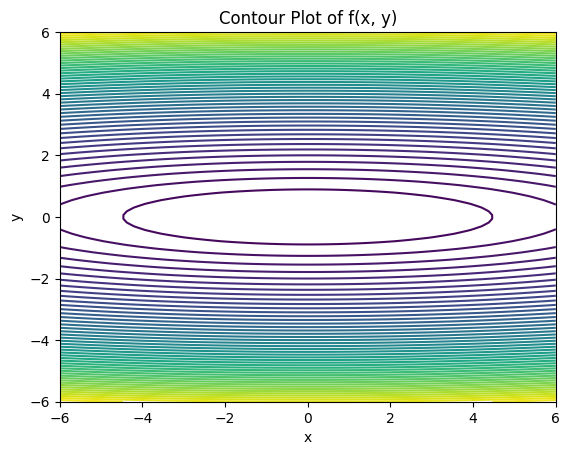

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as minimize

def f(x, y):
    return x**2 + 25*y**2

def gred(x, y):
    return np.array([2*x, 50*y])

X, Y = np.meshgrid(np.linspace(-6, 6, 100), np.linspace(-6, 6, 100))
Z = f(X, Y)

plt.contour(X, Y, Z, levels=50)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of f(x, y)')
plt.show()

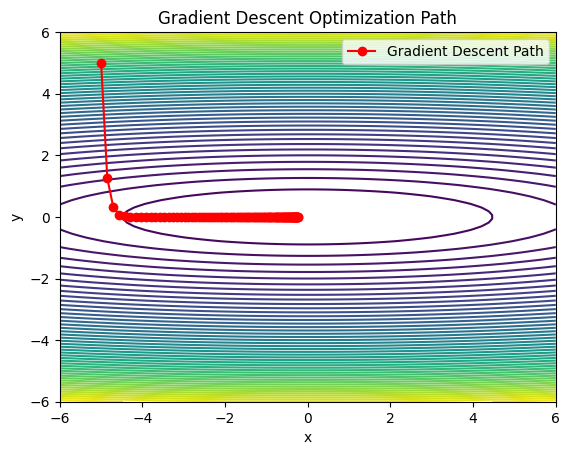

In [30]:
x, y = -5, 5
learning_rate = 0.015
path1 = [(x, y)]

for _ in range(100):
    grad = gred(x, y)
    x -= learning_rate * grad[0]
    y -= learning_rate * grad[1]
    path1.append((x, y))

plt.contour(X, Y, Z, levels=50)
path1 = np.array(path1)
# plt.plot(path1[:, 0], path1[:, 1], marker='o', color='red', label='Gradient Descent Path')
plt.plot(*zip(*path1), '-or', label='Gradient Descent Path')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent Optimization Path')
plt.legend()
plt.show()

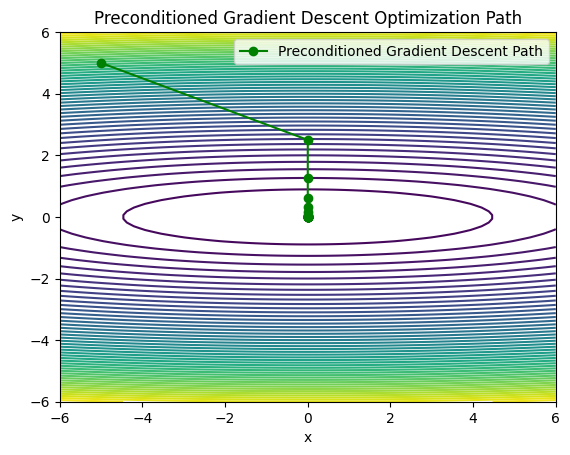

In [22]:
x, y = -5, 5
inv_curvature = np.array([1/2, 1/100])
path2 = [(x, y)]

for _ in range(30):
    g = gred(x, y)
    step = inv_curvature * g
    x, y = x - step[0], y - step[1]
    path2.append((x, y))
# path2 = np.array(path2)
plt.contour(X, Y, Z, levels=50)
plt.plot(*zip(*path2), '-og', label='Preconditioned Gradient Descent Path')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Preconditioned Gradient Descent Optimization Path')
plt.legend()
plt.show()

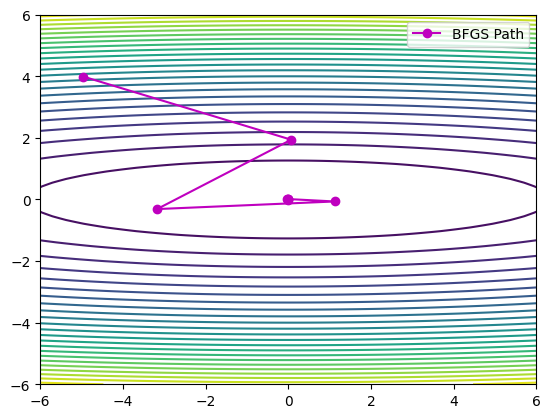

In [23]:
from scipy.optimize import minimize

def f_vec(v):
    return f(v[0], v[1])

path3 = []
def callback(v):
    path3.append(np.copy(v))

res = minimize(f_vec, x0=[-5, 5], method='BFGS', callback=callback)

plt.contour(X, Y, Z, levels=30)
plt.plot(*zip(*path3), '-om', label='BFGS Path')
plt.legend()
plt.show()